# Complexity Comparison: Lempel-Ziv (CLZ) vs Fourier Spectral Complexity

Two methods to map oscillating phenotype signals to a 1D complexity measure:

**Method 1 (CLZ):** Coarse-grain signal to 50 bins, encode derivative sign as binary string, compute Lempel-Ziv complexity.

**Method 2 (Fourier):** Compute FFT power spectrum, sort frequencies by power, find the smallest K such that the top-K frequencies capture $(1-\varepsilon)$ of total energy. Complexity = K.

In [57]:
import tellurium as te
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import platform
import roadrunner
import math
import warnings
from collections import Counter
warnings.filterwarnings('ignore')
roadrunner.Logger.setLevel(roadrunner.Logger.LOG_CRITICAL)

print("Complexity Comparison: CLZ vs Fourier Spectral")
print("=" * 50)

Complexity Comparison: CLZ vs Fourier Spectral


In [58]:
# === Model and parameter setup (from ChicoOscillation) ===

def get_model_path():
    linux_path = "/home/gijs/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"
    Beecroft_path = "/home/b/bartholomeus/Documents/OxfordEvolution/Yeast/Chen/chen_model.xml"
    mac_path = "/Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen_model.xml"
    for p in [linux_path, mac_path, Beecroft_path]:
        if os.path.exists(p):
            return p
    for rel_path in ["chen_model.xml", "Chen/chen_model.xml", "../Chen/chen_model.xml"]:
        if os.path.exists(rel_path):
            return os.path.abspath(rel_path)
    raise FileNotFoundError("Could not find chen_model.xml")

model_path = get_model_path()
print(f"Model: {model_path}")
rr = te.loadSBMLModel(model_path)

# Configuration
multipliers = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]
T = 1000
START = 100       # Analysis window start
END = 500         # Analysis window end
HANN = True       # Apply Hann window before FFT (reduces spectral leakage)
DIFFERENCE = True # Compute FFT on first difference d(t)=x(t+1)-x(t) instead of raw signal
SIMULATION_POINTS = 501
COARSE_BINS = 50
DIVERGENCE_THRESHOLD = 250
N_SAMPLES = int(1e4)  # 1e3 simulations
EPSILON = 0.05    # Fourier: capture 95% of energy

print(f"Samples: {N_SAMPLES}, T={T} min, Analysis window=[{START}, {END}] min")
print(f"eps={EPSILON}, Hann={HANN}, Difference={DIFFERENCE}")

Model: /Users/gijsbartholomeus/Documents/STUDIE/OxfordEvolution/code/Yeast/Chen/chen_model.xml
Samples: 10000, T=1000 min, Analysis window=[100, 500] min
eps=0.05, Hann=True, Difference=True


In [59]:
# === Core functions from ChicoOscillation ===

def get_kinetic_parameters(rr):
    kinetic_params = []
    for pid in rr.getGlobalParameterIds():
        value = rr.getValue(pid)
        param_lower = pid.lower()
        if (param_lower.endswith('t') and value in [0.0, 1.0]) or \
           (param_lower.startswith('d') and param_lower.endswith('n')) or \
           ('flag' in param_lower) or ('switch' in param_lower) or \
           (value == 0.0) or (pid in ['cell']) or \
           ('total' in param_lower and value in [0.0, 1.0]):
            continue
        kinetic_params.append(pid)
    return kinetic_params

def sample_parameters(rr, kinetic_params, default_values, wildtype=False):
    for pid, val in default_values.items():
        try:
            rr.setValue(pid, val)
        except RuntimeError:
            continue
    rr.resetAll()
    if wildtype:
        return
    for pid in kinetic_params:
        try:
            factor = random.choice(multipliers)
            rr.setValue(pid, default_values[pid] * factor)
        except (RuntimeError, KeyError):
            continue

def simulate(rr, T=500, npoints=501):
    rr.selections = ["time", "CLB2"]
    try:
        rr.integrator.absolute_tolerance = 1e-8
        rr.integrator.relative_tolerance = 1e-6
        result = rr.simulate(0, T, npoints)
    except RuntimeError:
        return None, None
    time_arr = result[:, 0]
    clb2 = result[:, 1]
    if np.any(np.abs(clb2) > DIVERGENCE_THRESHOLD):
        return None, None
    return time_arr, clb2

def coarse_grain(time_arr, signal, nbins=50):
    coarse_time = np.linspace(time_arr[0], time_arr[-1], nbins)
    coarse_signal = np.interp(coarse_time, time_arr, signal)
    return coarse_time, coarse_signal

def up_down_encoding(coarse_time, coarse_signal):
    slopes = np.diff(coarse_signal) / np.diff(coarse_time)
    return ''.join(['1' if s > 0 else '0' for s in slopes])

def lz76_phrase_count(s):
    n = len(s)
    if n == 0:
        return 0
    i = 0; c = 1; k = 1
    while i + k <= n:
        if s[i:i+k] in s[:i+k-1]:
            k += 1
            if i + k - 1 > n:
                c += 1
                break
        else:
            c += 1
            i += k
            k = 1
    return c

def CLZ(x):
    n = len(x)
    if x.count('0') == n or x.count('1') == n:
        return math.log2(n)
    return math.log2(n) / 2 * (lz76_phrase_count(x) + lz76_phrase_count(x[::-1]))

print("Core functions defined.")

Core functions defined.


In [60]:
# === Fourier Spectral Complexity ===

def fourier_complexity(signal, epsilon=0.05):
    """Compute spectral complexity of a signal.
    
    Complexity = minimum number of Fourier components (including DC/constant)
    needed to capture (1 - epsilon) of the total energy.
    
    A flat signal has complexity 1 (only DC component).
    A complex oscillating signal needs many components -> high complexity.
    
    Parameters
    ----------
    signal : array
        The time series signal.
    epsilon : float
        Tolerance. We find K so that top-K frequencies capture >= (1-epsilon)
        of total power.
    
    Returns
    -------
    K : int
        Number of frequency components needed.
    """
    # Compute FFT
    X = np.fft.rfft(signal)
    # Power spectrum (includes DC at index 0)
    P = np.abs(X) ** 2
    
    total_power = np.sum(P)
    if total_power == 0:
        return 1  # zero signal -> trivial
    
    # Sort by power descending
    sorted_power = np.sort(P)[::-1]
    
    # Find smallest K such that cumulative >= (1-epsilon) * total
    threshold = (1.0 - epsilon) * total_power
    cumulative = np.cumsum(sorted_power)
    K = int(np.searchsorted(cumulative, threshold)) + 1
    
    return K

# Quick sanity checks
flat = np.ones(100) * 5.0
sine = np.sin(2 * np.pi * np.linspace(0, 3, 100))
noise = np.random.randn(100)
multi = np.sin(2*np.pi*np.linspace(0,3,100)) + 0.5*np.sin(2*np.pi*7*np.linspace(0,3,100)) + 2.0

print(f"Flat signal complexity:    {fourier_complexity(flat)} (expect 1)")
print(f"Pure sine complexity:      {fourier_complexity(sine)} (expect ~1-2)")
print(f"Multi-frequency + DC:      {fourier_complexity(multi)} (expect ~3)")
print(f"Random noise complexity:   {fourier_complexity(noise)} (expect high)")

Flat signal complexity:    1 (expect 1)
Pure sine complexity:      1 (expect ~1-2)
Multi-frequency + DC:      2 (expect ~3)
Random noise complexity:   34 (expect high)


In [ ]:
# === Run N_SAMPLES simulations, compute both complexity measures ===
import time as time_module

rr_sim = te.loadSBMLModel(model_path)
kinetic_params = get_kinetic_parameters(rr_sim)
default_values = {}
for pid in rr_sim.getGlobalParameterIds():
    default_values[pid] = rr_sim.getValue(pid)

# Hann window size depends on whether we take the first difference
fft_len = COARSE_BINS - 1 if DIFFERENCE else COARSE_BINS
hann_window = np.hanning(fft_len) if HANN else np.ones(fft_len)

# Storage
results = []  # list of dicts with all data per successful simulation

start_t = time_module.time()
divergent = 0

for i in range(N_SAMPLES):
    sample_parameters(rr_sim, kinetic_params, default_values, wildtype=False)
    time_arr, clb2 = simulate(rr_sim, T=T, npoints=SIMULATION_POINTS)
    
    if time_arr is None:
        divergent += 1
        continue
    
    # Window to [START, END]
    mask = (time_arr >= START) & (time_arr <= END)
    time_win = time_arr[mask]
    clb2_win = clb2[mask]
    
    # CLZ complexity (on windowed signal, no Hann — CLZ uses derivative sign)
    ct, cs = coarse_grain(time_win, clb2_win, COARSE_BINS)
    encoding = up_down_encoding(ct, cs)
    clz_val = CLZ(encoding)
    
    # Fourier complexity: optionally first-difference, then Hann window
    cs_fft = np.diff(cs) if DIFFERENCE else cs
    cs_fft = cs_fft * hann_window
    fft_val = fourier_complexity(cs_fft, epsilon=EPSILON)
    
    results.append({
        'time': time_win,
        'clb2': clb2_win,
        'coarse_time': ct,
        'coarse_signal': cs,
        'coarse_signal_fft': cs_fft,
        'encoding': encoding,
        'clz': clz_val,
        'fft_K': fft_val,
    })
    
    if (i + 1) % 200 == 0:
        elapsed = time_module.time() - start_t
        print(f"  {i+1}/{N_SAMPLES} done ({elapsed:.1f}s, {(i+1)/elapsed:.1f}/s)")

elapsed = time_module.time() - start_t
print(f"\nDone: {len(results)} successful, {divergent} divergent, {elapsed:.1f}s")

# Also compute wildtype
sample_parameters(rr_sim, kinetic_params, default_values, wildtype=True)
wt_time, wt_clb2 = simulate(rr_sim, T=T, npoints=SIMULATION_POINTS)
wt_mask = (wt_time >= START) & (wt_time <= END)
wt_time_win = wt_time[wt_mask]
wt_clb2_win = wt_clb2[wt_mask]
wt_ct, wt_cs = coarse_grain(wt_time_win, wt_clb2_win, COARSE_BINS)
wt_encoding = up_down_encoding(wt_ct, wt_cs)
wt_clz = CLZ(wt_encoding)
wt_cs_fft = np.diff(wt_cs) if DIFFERENCE else wt_cs
wt_cs_fft = wt_cs_fft * hann_window
wt_fft = fourier_complexity(wt_cs_fft, epsilon=EPSILON)
print(f"Wildtype: CLZ={wt_clz:.2f}, Fourier K={wt_fft}")

  200/10000 done (7.2s, 27.6/s)
  400/10000 done (14.6s, 27.3/s)
  600/10000 done (21.6s, 27.8/s)
  1000/10000 done (35.7s, 28.0/s)
  1400/10000 done (49.7s, 28.2/s)


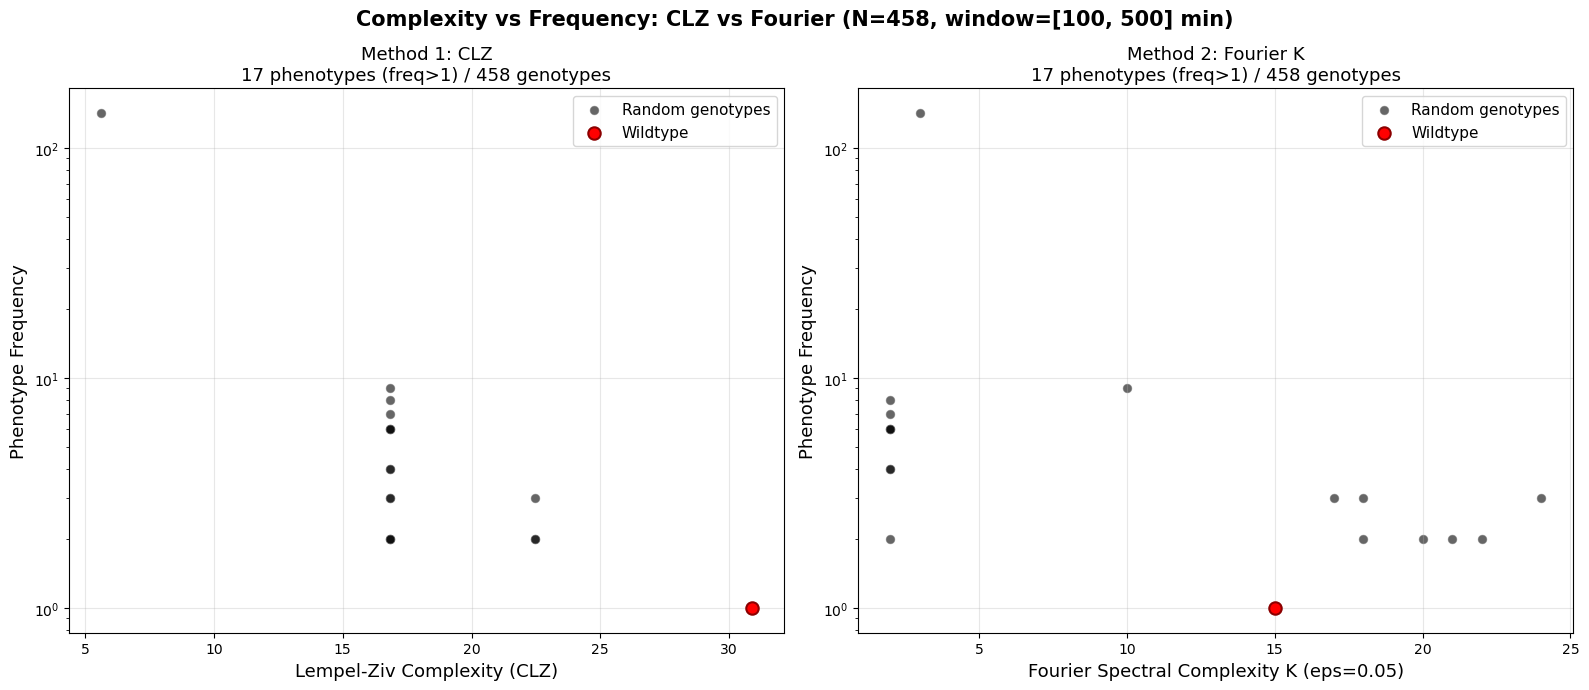

Saved: plots/complexity_comparison_clz_vs_fourier.png


In [ ]:
# === Side-by-side complexity vs frequency plots ===

# Count phenotype frequencies (by encoding string, shared across methods)
all_encodings = [r['encoding'] for r in results]
phenotype_counts = Counter(all_encodings)

# Build per-phenotype data
phenotype_clz = {}
phenotype_fft = {}
for r in results:
    enc = r['encoding']
    phenotype_clz[enc] = r['clz']
    phenotype_fft[enc] = r['fft_K']

# Prepare arrays for plotting (one point per unique phenotype)
plot_clz = []
plot_fft = []
plot_freq = []
for enc, freq in phenotype_counts.items():
    plot_clz.append(phenotype_clz[enc])
    plot_fft.append(phenotype_fft[enc])
    plot_freq.append(freq)

plot_clz = np.array(plot_clz)
plot_fft = np.array(plot_fft)
plot_freq = np.array(plot_freq)

# Wildtype frequency
wt_freq = phenotype_counts.get(wt_encoding, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Method 1: CLZ ---
mask1 = plot_freq > 1
ax1.scatter(plot_clz[mask1], plot_freq[mask1], alpha=0.6, s=40, c='black',
            edgecolors='gray', linewidth=0.5, label='Random genotypes')
ax1.scatter(wt_clz, wt_freq, color='red', s=80, marker='o',
            edgecolors='darkred', linewidth=1.5, zorder=10, label='Wildtype')
ax1.set_xlabel('Lempel-Ziv Complexity (CLZ)', fontsize=13)
ax1.set_ylabel('Phenotype Frequency', fontsize=13)
ax1.set_yscale('log')
ax1.set_title(f'Method 1: CLZ\n{np.sum(mask1)} phenotypes (freq>1) / {len(results)} genotypes', fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# --- Method 2: Fourier K ---
ax2.scatter(plot_fft[mask1], plot_freq[mask1], alpha=0.6, s=40, c='black',
            edgecolors='gray', linewidth=0.5, label='Random genotypes')
ax2.scatter(wt_fft, wt_freq, color='red', s=80, marker='o',
            edgecolors='darkred', linewidth=1.5, zorder=10, label='Wildtype')
ax2.set_xlabel(f'Fourier Spectral Complexity K (eps={EPSILON})', fontsize=13)
ax2.set_ylabel('Phenotype Frequency', fontsize=13)
ax2.set_yscale('log')
ax2.set_title(f'Method 2: Fourier K\n{np.sum(mask1)} phenotypes (freq>1) / {len(results)} genotypes', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

fig.suptitle(f'Complexity vs Frequency: CLZ vs Fourier (N={len(results)}, window=[{START}, {END}] min)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/complexity_comparison_clz_vs_fourier.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/complexity_comparison_clz_vs_fourier.png")

In [ ]:
# === Exemplary curves: low and high complexity for both methods ===

clz_values = np.array([r['clz'] for r in results])
fft_values = np.array([r['fft_K'] for r in results])

# Percentile thresholds
clz_p20 = np.percentile(clz_values, 20)
clz_p80 = np.percentile(clz_values, 80)
fft_p20 = np.percentile(fft_values, 20)
fft_p80 = np.percentile(fft_values, 80)

print(f"CLZ: 20th={clz_p20:.2f}, 80th={clz_p80:.2f}")
print(f"FFT: 20th={fft_p20}, 80th={fft_p80}")

# Get indices for each regime
idx_clz_low = [i for i, r in enumerate(results) if r['clz'] <= clz_p20]
idx_clz_high = [i for i, r in enumerate(results) if r['clz'] >= clz_p80]
idx_fft_low = [i for i, r in enumerate(results) if r['fft_K'] <= fft_p20]
idx_fft_high = [i for i, r in enumerate(results) if r['fft_K'] >= fft_p80]

# Pick 4 random examples from each
rng = np.random.default_rng(42)
pick = lambda idxs: rng.choice(idxs, size=min(4, len(idxs)), replace=False)

sel_clz_low = pick(idx_clz_low)
sel_clz_high = pick(idx_clz_high)
sel_fft_low = pick(idx_fft_low)
sel_fft_high = pick(idx_fft_high)

print(f"\nSelected indices:")
print(f"  CLZ low:  {sel_clz_low}")
print(f"  CLZ high: {sel_clz_high}")
print(f"  FFT low:  {sel_fft_low}")
print(f"  FFT high: {sel_fft_high}")

CLZ: 20th=5.61, 80th=30.88
FFT: 20th=2.0, 80th=18.600000000000023

Selected indices:
  CLZ low:  [209  44 299 350]
  CLZ high: [304  82  46 240]
  FFT low:  [311 214 355  53]
  FFT high: [173 351  77 416]


In [ ]:
# === Plot function for 2x2 exemplary curves ===

def plot_exemplary_curves(indices, method_name, regime, complexity_key, results_list):
    """Plot 2x2 grid of exemplary phenotype curves."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for j, idx in enumerate(indices):
        r = results_list[idx]
        ax = axes[j]
        
        # Plot full signal
        ax.plot(r['time'], r['clb2'], 'b-', linewidth=1, alpha=0.6, label='CLB2')
        # Overlay the signal that was fed to FFT
        ct = r['coarse_time']
        cs_fft = r['coarse_signal_fft']
        if DIFFERENCE:
            # First difference has length n-1, plot at midpoints
            ct_mid = 0.5 * (ct[:-1] + ct[1:])
            ax.plot(ct_mid, cs_fft, 'ro-', markersize=3,
                    linewidth=1.5, alpha=0.8, label='Diff' + (' + Hann' if HANN else ''))
        elif HANN:
            ax.plot(ct, cs_fft, 'ro-', markersize=3,
                    linewidth=1.5, alpha=0.8, label='Coarse (Hann)')
        else:
            ax.plot(ct, r['coarse_signal'], 'ro-', markersize=3,
                    linewidth=1.5, alpha=0.8, label='Coarse-grained')
        
        clz_v = r['clz']
        fft_v = r['fft_K']
        ax.set_title(f'CLZ={clz_v:.1f}, Fourier K={fft_v}', fontsize=11)
        ax.set_xlabel('Time (min)', fontsize=10)
        ax.set_ylabel('CLB2', fontsize=10)
        ax.grid(True, alpha=0.3)
        if j == 0:
            ax.legend(fontsize=9)
    
    fig.suptitle(f'{method_name}: {regime} complexity (lowest/highest 20%)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'plots/exemplary_{method_name.lower().replace(" ","_")}_{regime.lower()}.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

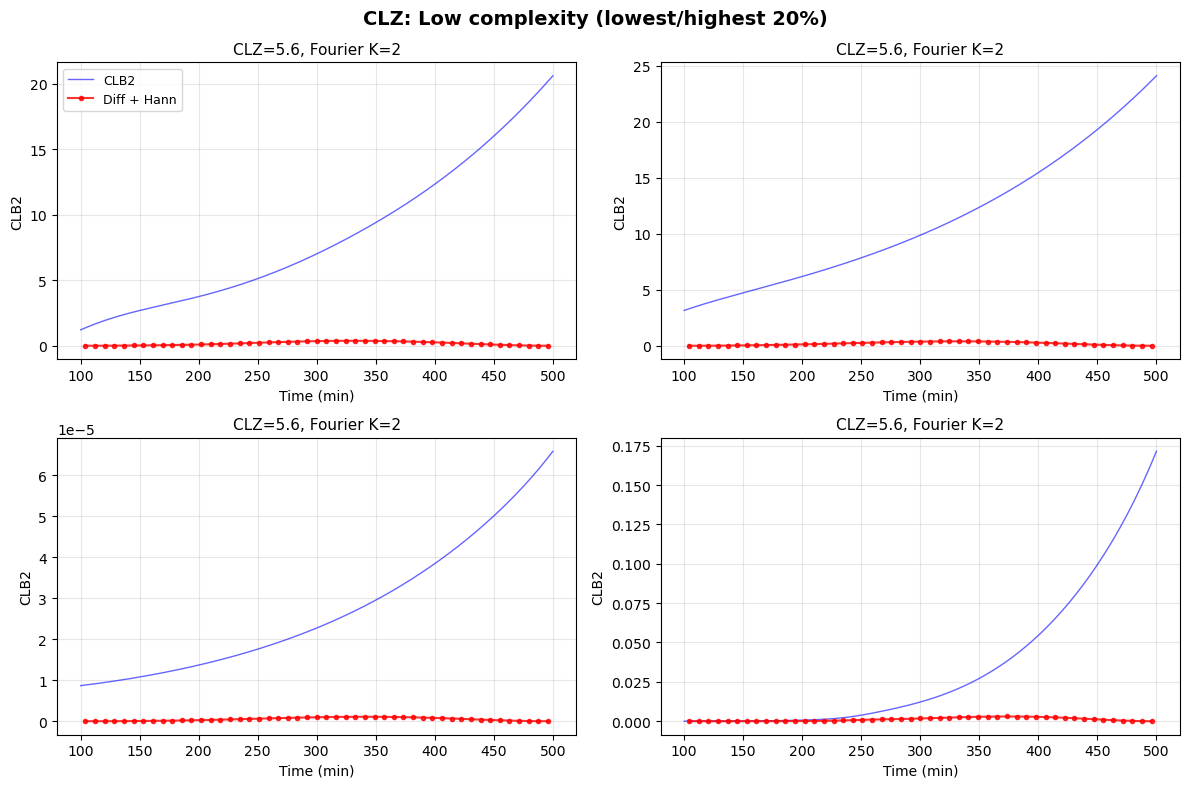

Saved: plots/exemplary_clz_low.png


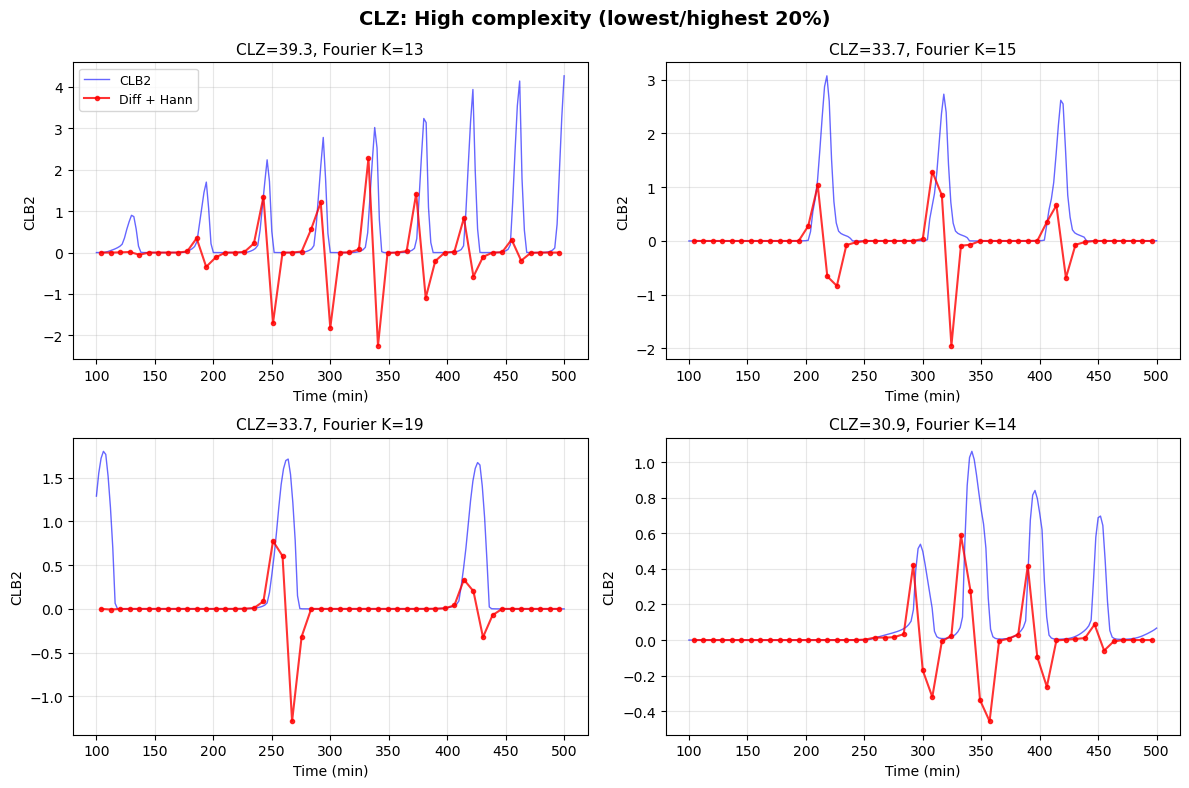

Saved: plots/exemplary_clz_high.png


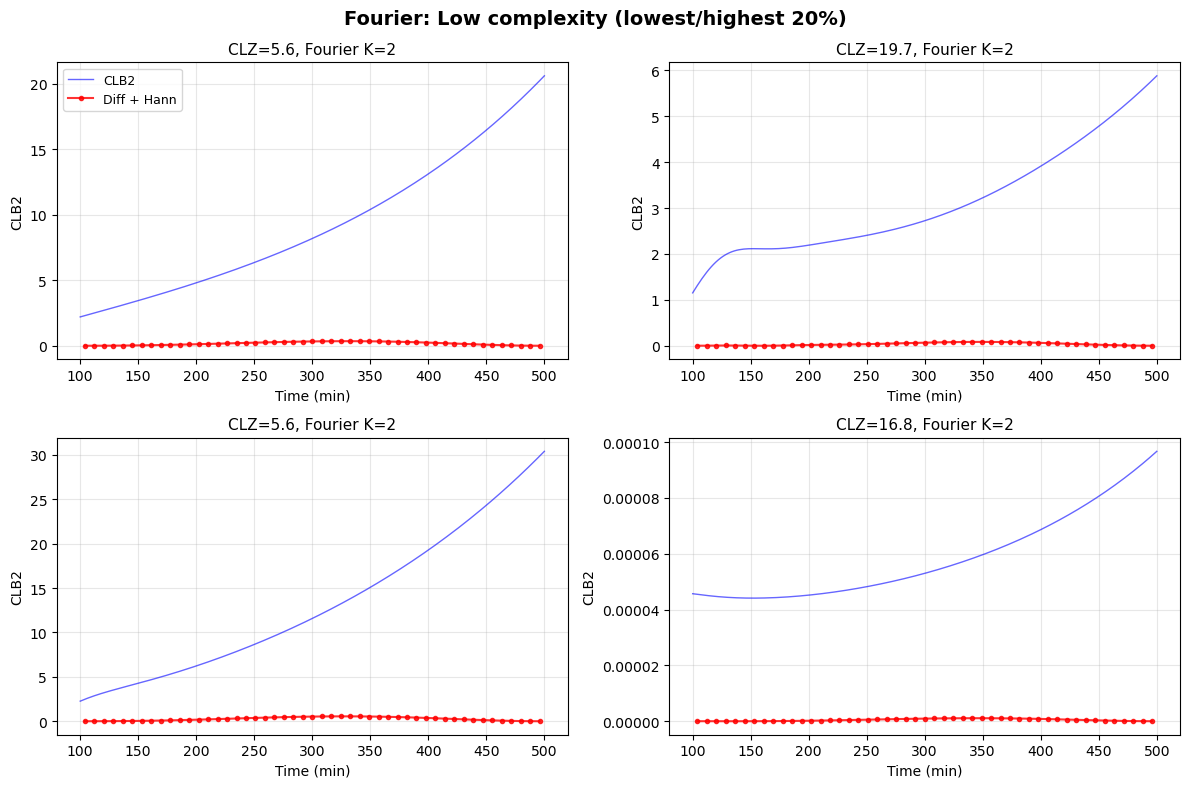

Saved: plots/exemplary_fourier_low.png


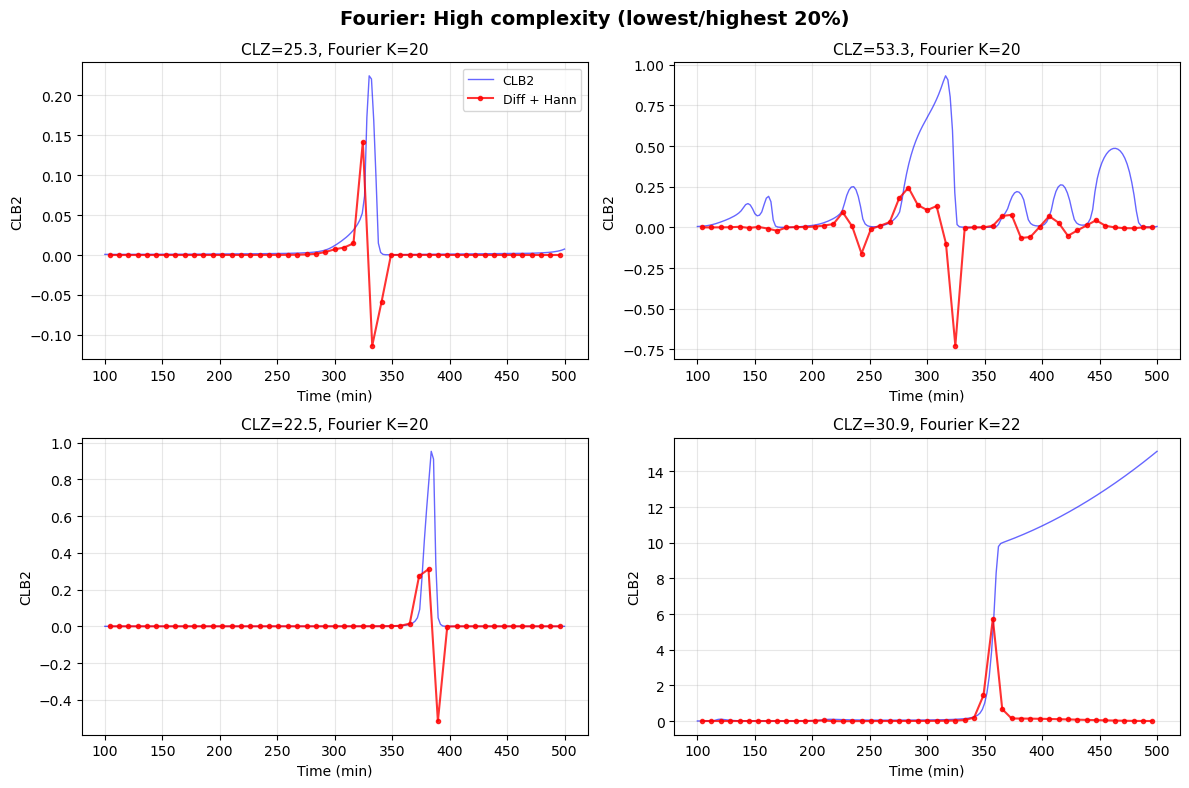

Saved: plots/exemplary_fourier_high.png


In [ ]:
# === 4 plots: low/high x CLZ/Fourier ===

plot_exemplary_curves(sel_clz_low, 'CLZ', 'Low', 'clz', results)
plot_exemplary_curves(sel_clz_high, 'CLZ', 'High', 'clz', results)
plot_exemplary_curves(sel_fft_low, 'Fourier', 'Low', 'fft_K', results)
plot_exemplary_curves(sel_fft_high, 'Fourier', 'High', 'fft_K', results)

CLZ low & FFT high: 8 candidates
CLZ high & FFT low: 0 candidates
  (relaxed to median) CLZ high & FFT low: 58


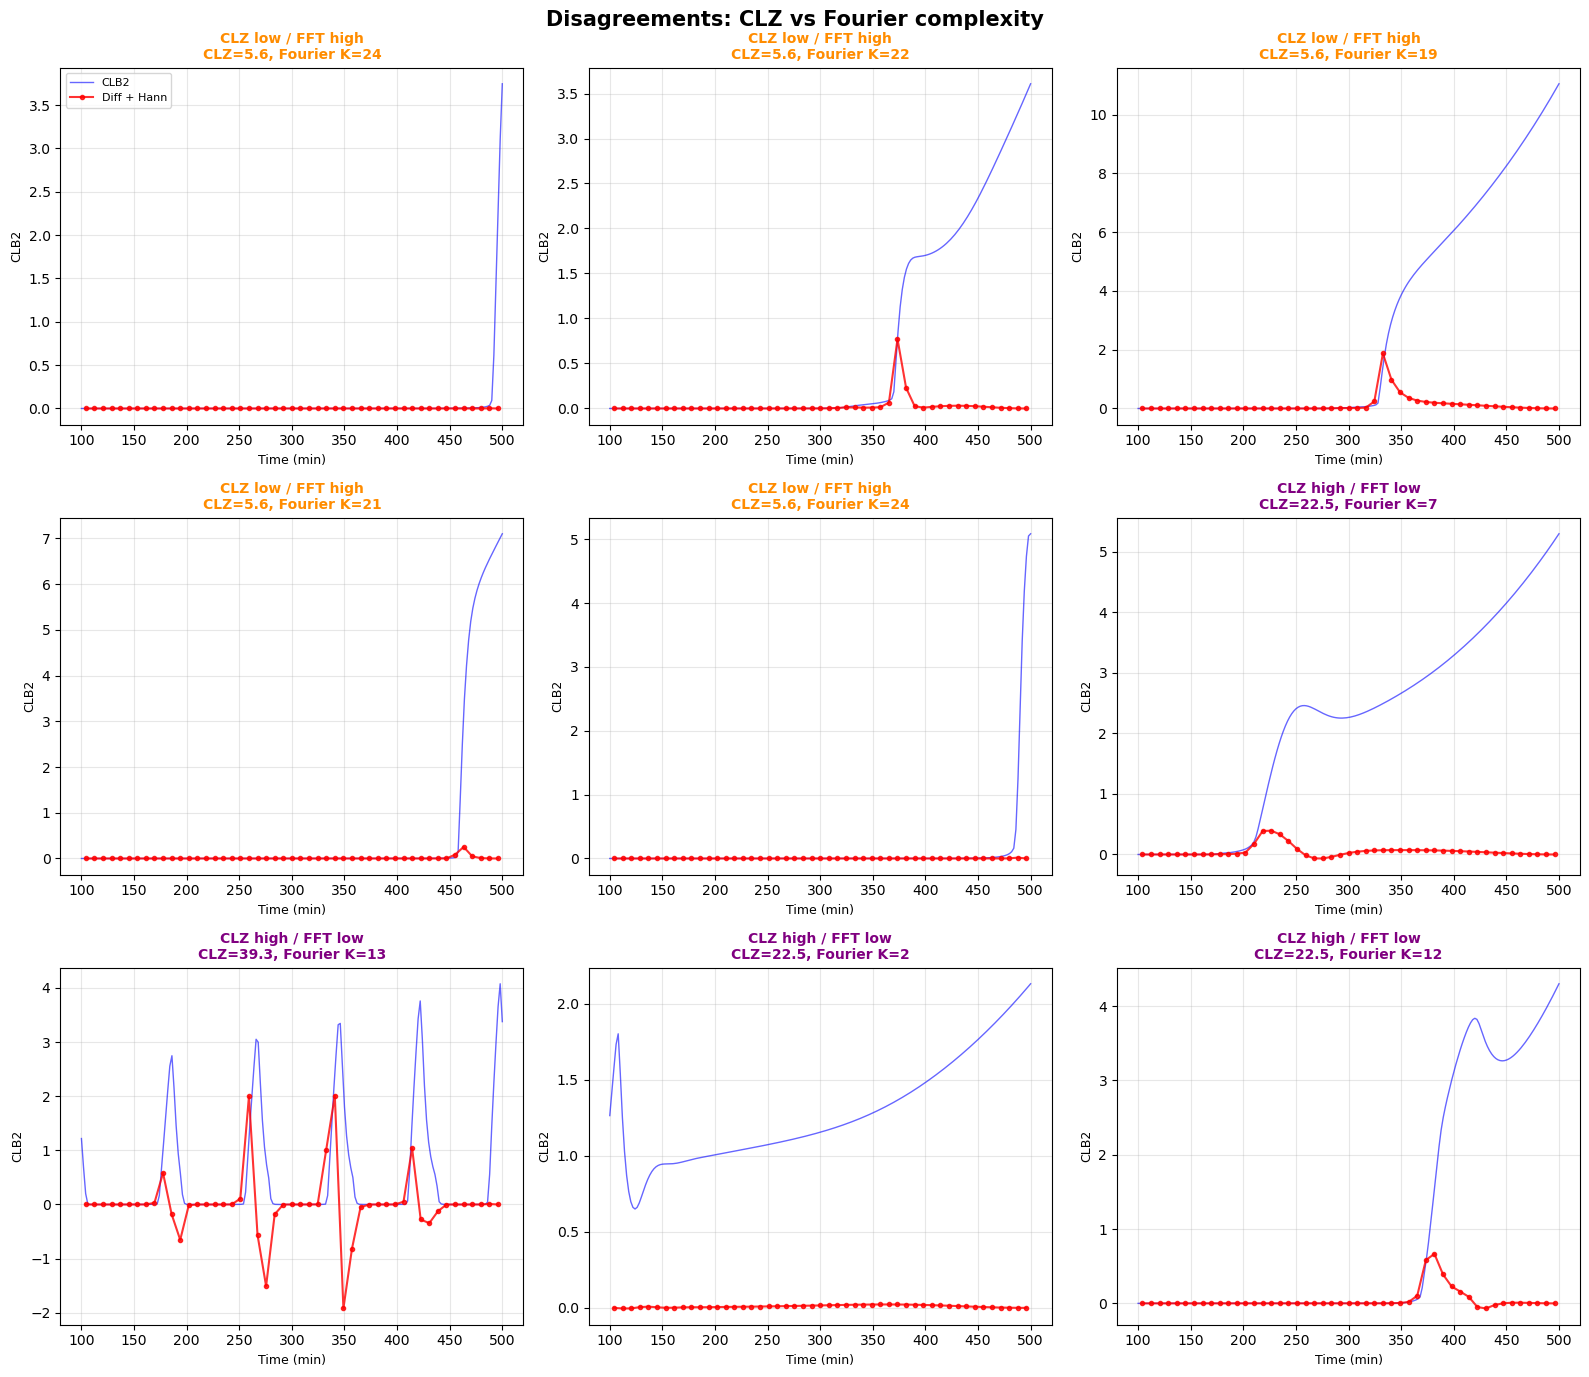

Saved: plots/complexity_disagreements_clz_vs_fourier.png


In [ ]:
# === 3x3 Disagreement plot: cases where CLZ and Fourier disagree ===

# Median split for "low" vs "high"
clz_med = np.median(clz_values)
fft_med = np.median(fft_values)

# CLZ low + FFT high
idx_clz_low_fft_high = [i for i in range(len(results))
                        if results[i]['clz'] <= clz_p20 and results[i]['fft_K'] >= fft_p80]
# CLZ high + FFT low
idx_clz_high_fft_low = [i for i in range(len(results))
                        if results[i]['clz'] >= clz_p80 and results[i]['fft_K'] <= fft_p20]

print(f"CLZ low & FFT high: {len(idx_clz_low_fft_high)} candidates")
print(f"CLZ high & FFT low: {len(idx_clz_high_fft_low)} candidates")

# If strict percentile thresholds yield too few, relax to median
if len(idx_clz_low_fft_high) < 5:
    idx_clz_low_fft_high = [i for i in range(len(results))
                            if results[i]['clz'] <= clz_med and results[i]['fft_K'] >= fft_med]
    print(f"  (relaxed to median) CLZ low & FFT high: {len(idx_clz_low_fft_high)}")
if len(idx_clz_high_fft_low) < 4:
    idx_clz_high_fft_low = [i for i in range(len(results))
                            if results[i]['clz'] >= clz_med and results[i]['fft_K'] <= fft_med]
    print(f"  (relaxed to median) CLZ high & FFT low: {len(idx_clz_high_fft_low)}")

rng_dis = np.random.default_rng(123)
sel_clz_lo_fft_hi = rng_dis.choice(idx_clz_low_fft_high,
                                    size=min(5, len(idx_clz_low_fft_high)), replace=False)
sel_clz_hi_fft_lo = rng_dis.choice(idx_clz_high_fft_low,
                                    size=min(4, len(idx_clz_high_fft_low)), replace=False)

all_disagree = list(sel_clz_lo_fft_hi) + list(sel_clz_hi_fft_lo)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for j, idx in enumerate(all_disagree):
    r = results[idx]
    ax = axes[j]

    ax.plot(r['time'], r['clb2'], 'b-', linewidth=1, alpha=0.6, label='CLB2')
    ct = r['coarse_time']
    cs_fft = r['coarse_signal_fft']
    if DIFFERENCE:
        ct_mid = 0.5 * (ct[:-1] + ct[1:])
        ax.plot(ct_mid, cs_fft, 'ro-', markersize=3,
                linewidth=1.5, alpha=0.8, label='Diff' + (' + Hann' if HANN else ''))
    elif HANN:
        ax.plot(ct, cs_fft, 'ro-', markersize=3,
                linewidth=1.5, alpha=0.8, label='Coarse (Hann)')
    else:
        ax.plot(ct, r['coarse_signal'], 'ro-', markersize=3,
                linewidth=1.5, alpha=0.8, label='Coarse-grained')

    category = 'CLZ low / FFT high' if j < len(sel_clz_lo_fft_hi) else 'CLZ high / FFT low'
    color = 'darkorange' if j < len(sel_clz_lo_fft_hi) else 'purple'
    ax.set_title(f'{category}\nCLZ={r["clz"]:.1f}, Fourier K={r["fft_K"]}',
                 fontsize=10, color=color, fontweight='bold')
    ax.set_xlabel('Time (min)', fontsize=9)
    ax.set_ylabel('CLB2', fontsize=9)
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.legend(fontsize=8)

# Hide unused subplots if fewer than 9
for j in range(len(all_disagree), 9):
    axes[j].set_visible(False)

fig.suptitle('Disagreements: CLZ vs Fourier complexity',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/complexity_disagreements_clz_vs_fourier.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: plots/complexity_disagreements_clz_vs_fourier.png")

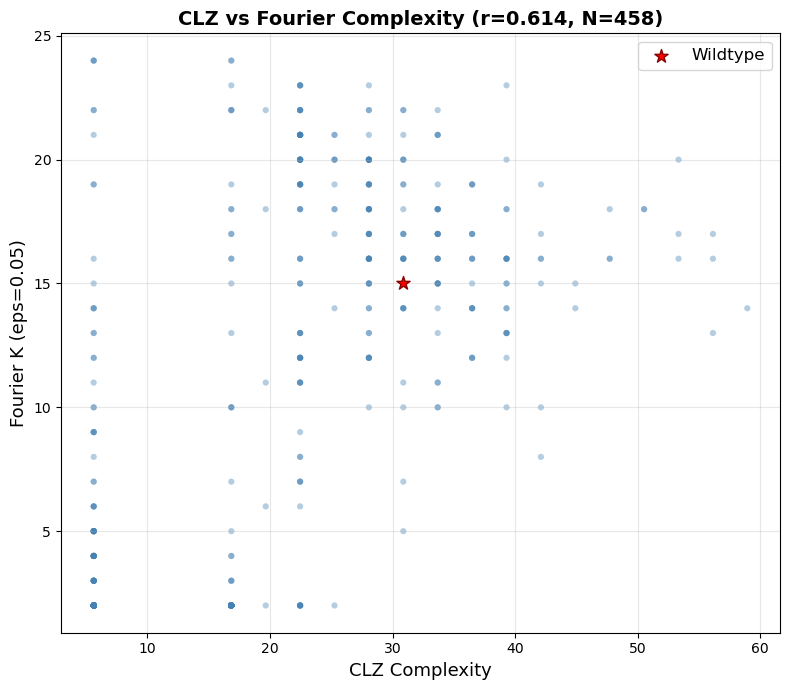

Pearson r = 0.614
Saved: plots/complexity_clz_vs_fourier_correlation.png


In [ ]:
# === Correlation between the two methods ===

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(clz_values, fft_values, alpha=0.4, s=20, c='steelblue', edgecolors='none')
ax.scatter(wt_clz, wt_fft, color='red', s=100, marker='*',
           edgecolors='darkred', linewidth=1, zorder=10, label='Wildtype')

corr = np.corrcoef(clz_values, fft_values)[0, 1]
ax.set_xlabel('CLZ Complexity', fontsize=13)
ax.set_ylabel(f'Fourier K (eps={EPSILON})', fontsize=13)
ax.set_title(f'CLZ vs Fourier Complexity (r={corr:.3f}, N={len(results)})',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('plots/complexity_clz_vs_fourier_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Pearson r = {corr:.3f}")
print(f"Saved: plots/complexity_clz_vs_fourier_correlation.png")

In [ ]:
# === Summary statistics ===

print("=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"Samples: {N_SAMPLES} attempted, {len(results)} successful, {divergent} divergent")
print(f"Simulation: [0, {T}] min, Analysis window: [{START}, {END}] min")
print(f"")
print(f"CLZ Complexity:")
print(f"  Range: [{clz_values.min():.2f}, {clz_values.max():.2f}]")
print(f"  Mean:  {clz_values.mean():.2f} +/- {clz_values.std():.2f}")
print(f"  Wildtype: {wt_clz:.2f}")
print(f"")
print(f"Fourier K (eps={EPSILON}):")
print(f"  Range: [{fft_values.min()}, {fft_values.max()}]")
print(f"  Mean:  {fft_values.mean():.2f} +/- {fft_values.std():.2f}")
print(f"  Wildtype: {wt_fft}")
print(f"")
print(f"Correlation: r = {corr:.3f}")
print(f"Unique phenotypes: {len(phenotype_counts)}")

SUMMARY
Samples: 1000 attempted, 458 successful, 542 divergent
Simulation: [0, 1000] min, Analysis window: [100, 500] min

CLZ Complexity:
  Range: [5.61, 58.95]
  Mean:  20.69 +/- 12.53
  Wildtype: 30.88

Fourier K (eps=0.05):
  Range: [2, 24]
  Mean:  11.08 +/- 7.42
  Wildtype: 15

Correlation: r = 0.614
Unique phenotypes: 264
